# Metrics Harness — Measure & Compare
# 
# This notebook measures execution latency, kernel reliability, and sync correctness
# against the committed baseline. Run cells interactively to iterate on measurements
# or visualize trends.

In [3]:
import asyncio
import json
import os
import subprocess
import time
import statistics
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update(
    {
        "figure.facecolor": "#1a1a2e",
        "axes.facecolor": "#16213e",
        "text.color": "#e0e0e0",
        "axes.labelcolor": "#e0e0e0",
        "xtick.color": "#e0e0e0",
        "ytick.color": "#e0e0e0",
        "figure.figsize": (10, 4),
    }
)

from runtimed import Client

# Load baseline (resolve relative to this notebook's location)
baseline_path = Path("baseline.json")
if not baseline_path.exists():
    baseline_path = Path.cwd() / "scripts" / "metrics" / "baseline.json"
baseline = json.loads(baseline_path.read_text()) if baseline_path.exists() else None


def get_baseline(name):
    return baseline["metrics"].get(name) if baseline else None


print(f"Baseline: {baseline['git_ref'] if baseline else 'none'}")
print("Ready")

Baseline: b0396bfa
Ready


## Execution Latency

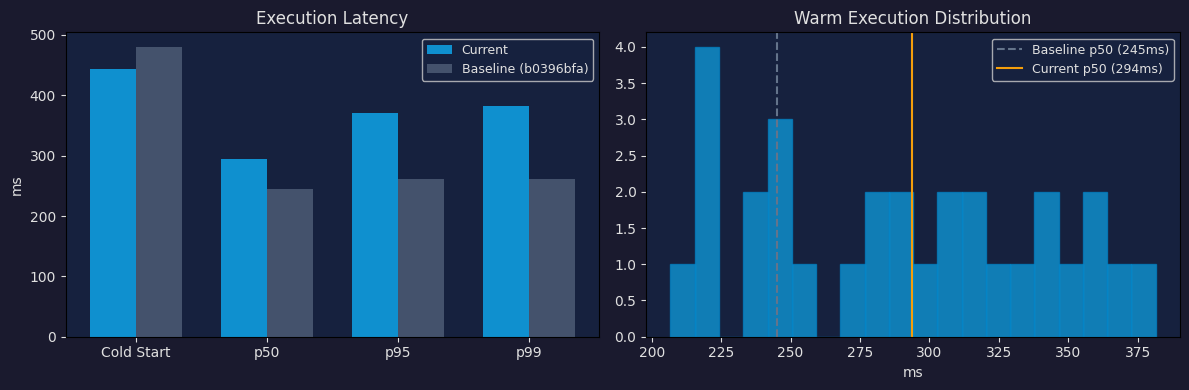

Cold: 444ms | p50: 294ms | p95: 372ms | n=30


In [12]:
async def measure_latency(n=30):
    """Measure execution round-trip latency inline."""
    client = Client(peer_label="notebook:latency")
    notebook = await client.create_notebook()
    await notebook.start()

    # Wait for kernel
    for _ in range(300):
        if notebook.runtime.kernel.status in ("idle", "busy"):
            break
        await asyncio.sleep(0.2)

    cell = await notebook.cells.create(source="1+1")

    # Cold start
    t0 = time.monotonic()
    await cell.run(timeout_secs=30)
    cold_ms = (time.monotonic() - t0) * 1000

    # Warm executions
    warm = []
    for _ in range(n):
        t0 = time.monotonic()
        result = await cell.run(timeout_secs=15)
        if result.success:
            warm.append((time.monotonic() - t0) * 1000)

    await notebook.disconnect()
    warm.sort()
    m = len(warm)
    return {
        "cold_start_ms": round(cold_ms, 1),
        "warm_p50_ms": round(warm[m // 2], 1),
        "warm_p95_ms": round(warm[int(m * 0.95)], 1),
        "warm_p99_ms": round(warm[int(m * 0.99)], 1),
        "warm_mean_ms": round(statistics.mean(warm), 1),
        "warm_min_ms": round(warm[0], 1),
        "warm_max_ms": round(warm[-1], 1),
        "n": m,
        "all_times": warm,
    }


latency = await measure_latency(30)

bl = get_baseline("execution_latency")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

keys = ["cold_start_ms", "warm_p50_ms", "warm_p95_ms", "warm_p99_ms"]
labels = ["Cold Start", "p50", "p95", "p99"]
current_vals = [latency[k] for k in keys]

x = range(len(labels))
ax1.bar(x, current_vals, color="#0ea5e9", alpha=0.85, label="Current", width=0.35)
if bl:
    baseline_vals = [bl[k] for k in keys]
    ax1.bar(
        [i + 0.35 for i in x],
        baseline_vals,
        color="#64748b",
        alpha=0.6,
        width=0.35,
        label=f"Baseline ({baseline['git_ref']})",
    )
ax1.set_xticks([i + 0.175 for i in x])
ax1.set_xticklabels(labels)
ax1.set_ylabel("ms")
ax1.set_title("Execution Latency")
ax1.legend(fontsize=9)

# Distribution of warm times
ax2.hist(latency["all_times"], bins=20, color="#0ea5e9", alpha=0.7, edgecolor="#0284c7")
if bl:
    ax2.axvline(
        bl["warm_p50_ms"],
        color="#64748b",
        linestyle="--",
        label=f"Baseline p50 ({bl['warm_p50_ms']:.0f}ms)",
    )
ax2.axvline(
    latency["warm_p50_ms"],
    color="#f59e0b",
    linestyle="-",
    label=f"Current p50 ({latency['warm_p50_ms']:.0f}ms)",
)
ax2.set_xlabel("ms")
ax2.set_title("Warm Execution Distribution")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(
    f"Cold: {latency['cold_start_ms']:.0f}ms | p50: {latency['warm_p50_ms']:.0f}ms | "
    f"p95: {latency['warm_p95_ms']:.0f}ms | n={latency['n']}"
)

## Kernel Reliability

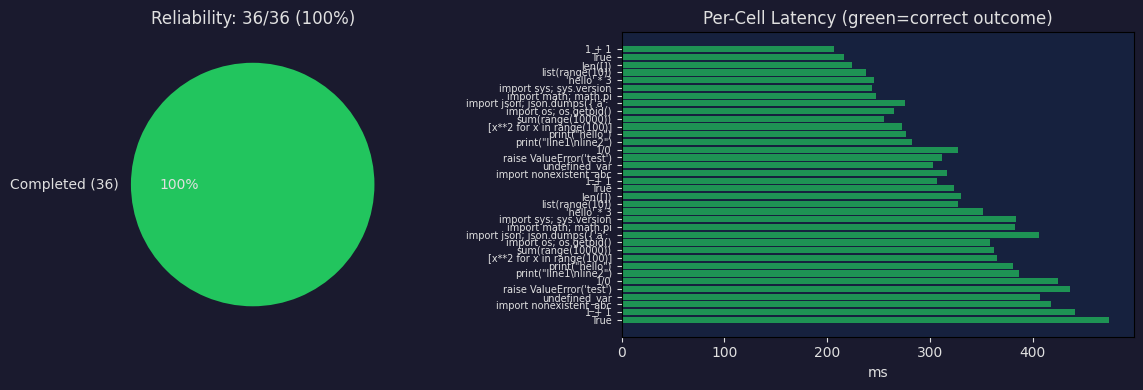

Completed: 36/36 | Correct outcome: 36/36 | Timeouts: 0


In [13]:
CELL_BATTERY = [
    ("1 + 1", True),
    ("True", True),
    ("len([])", True),
    ("list(range(10))", True),
    ("'hello' * 3", True),
    ("import sys; sys.version", True),
    ("import math; math.pi", True),
    ("import json; json.dumps({'a': 1})", True),
    ("import os; os.getpid()", True),
    ("sum(range(10000))", True),
    ("[x**2 for x in range(100)]", True),
    ('print("hello")', True),
    ('print("line1\\nline2")', True),
    ("1/0", False),
    ("raise ValueError('test')", False),
    ("undefined_var", False),
    ("import nonexistent_abc", False),
]


async def measure_reliability(rounds=36):
    """Run a diverse battery of cell executions."""
    client = Client(peer_label="notebook:reliability")
    notebook = await client.create_notebook()
    await notebook.start()
    for _ in range(300):
        if notebook.runtime.kernel.status in ("idle", "busy"):
            break
        await asyncio.sleep(0.2)

    results = []
    for i in range(rounds):
        source, expect_success = CELL_BATTERY[i % len(CELL_BATTERY)]
        cell = await notebook.cells.create(source=source)
        t0 = time.monotonic()
        try:
            result = await cell.run(timeout_secs=15)
            elapsed = (time.monotonic() - t0) * 1000
            results.append(
                {
                    "source": source[:30],
                    "completed": True,
                    "timed_out": False,
                    "success": result.success,
                    "expected": expect_success,
                    "correct": result.success == expect_success,
                    "ms": round(elapsed, 1),
                }
            )
        except asyncio.TimeoutError:
            results.append(
                {
                    "source": source[:30],
                    "completed": False,
                    "timed_out": True,
                    "success": None,
                    "expected": expect_success,
                    "correct": False,
                    "ms": 15000,
                }
            )
        try:
            await cell.delete()
        except Exception:
            pass

    await notebook.disconnect()
    return results


reliability = await measure_reliability(36)
completed = sum(1 for r in reliability if r["completed"])
correct = sum(1 for r in reliability if r["correct"])
timed_out = sum(1 for r in reliability if r["timed_out"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
colors_pie = ["#22c55e", "#ef4444", "#f59e0b"]
sizes = [completed, len(reliability) - completed - timed_out, timed_out]
labels_pie = [
    f"Completed ({completed})",
    f"Failed ({len(reliability) - completed - timed_out})",
    f"Timeout ({timed_out})",
]
# Filter out zeros
active = [(s, l, c) for s, l, c in zip(sizes, labels_pie, colors_pie) if s > 0]
if active:
    ax1.pie(
        [a[0] for a in active],
        labels=[a[1] for a in active],
        colors=[a[2] for a in active],
        autopct="%1.0f%%",
        textprops={"color": "#e0e0e0"},
    )
ax1.set_title(
    f"Reliability: {completed}/{len(reliability)} ({completed / len(reliability) * 100:.0f}%)"
)

# Latency per cell type
times = [r["ms"] for r in reliability if r["completed"]]
labels_bar = [r["source"] for r in reliability if r["completed"]]
colors_bar = ["#22c55e" if r["correct"] else "#ef4444" for r in reliability if r["completed"]]
ax2.barh(range(len(times)), times, color=colors_bar, alpha=0.7, height=0.8)
ax2.set_yticks(range(len(times)))
ax2.set_yticklabels(labels_bar, fontsize=7)
ax2.set_xlabel("ms")
ax2.set_title("Per-Cell Latency (green=correct outcome)")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print(
    f"Completed: {completed}/{len(reliability)} | Correct outcome: {correct}/{len(reliability)} | Timeouts: {timed_out}"
)

## Sync Correctness

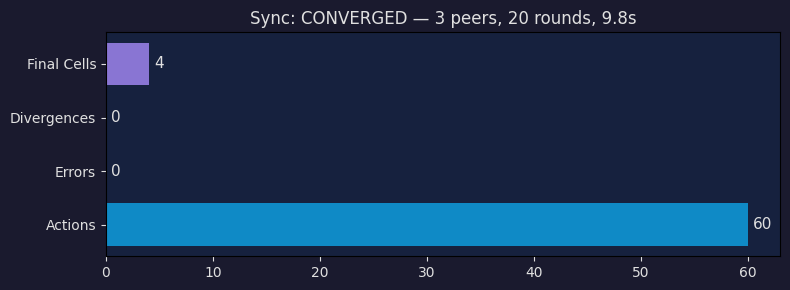

Converged: True | 60 actions, 0 errors, 9.8s


In [14]:
import random
import contextlib


async def measure_sync(n_peers=3, rounds=20, seed=42):
    """Run concurrent CRDT mutations across peers and check convergence."""
    random.seed(seed)
    snippets = ["1+1", "list(range(5))", "'hello'*3", "sum(range(100))", "True"]

    # Create notebook
    client = Client(peer_label="notebook:sync-setup")
    notebook = await client.create_notebook()
    notebook_id = notebook.notebook_id
    await notebook.cells.create(source="# sync test\n1+1")
    await notebook.disconnect()

    async def run_peer(peer_id):
        c = Client(peer_label=f"sync-peer-{peer_id}")
        nb = await c.join_notebook(notebook_id)
        # wait for sync
        for _ in range(50):
            if nb.cells.ids:
                break
            await asyncio.sleep(0.1)

        actions, errors = 0, 0
        for _ in range(rounds):
            actions += 1
            try:
                action = random.choice(["create", "edit", "delete"])
                ids = nb.cells.ids
                if action == "create":
                    await nb.cells.create(source=f"# peer-{peer_id}\n{random.choice(snippets)}")
                elif action == "edit" and ids:
                    cell = nb.cells[random.choice(ids)]
                    await cell.append(f"\n# edit-{peer_id}")
                elif action == "delete" and len(ids) > 1:
                    await nb.cells[random.choice(ids)].delete()
            except Exception:
                errors += 1
            await asyncio.sleep(0.1 + random.uniform(0, 0.2))
        return {"nb": nb, "actions": actions, "errors": errors}

    t0 = time.monotonic()
    results = await asyncio.gather(*[run_peer(i) for i in range(n_peers)], return_exceptions=True)
    elapsed = time.monotonic() - t0

    # Settle
    await asyncio.sleep(3)

    # Read state from each peer
    states = []
    notebooks = []
    total_actions, total_errors = 0, 0
    for r in results:
        if isinstance(r, Exception):
            total_errors += 1
            continue
        total_actions += r["actions"]
        total_errors += r["errors"]
        nb = r["nb"]
        notebooks.append(nb)
        ids = nb.cells.ids
        cells = [(cid, nb.cells[cid].source[:50]) for cid in ids]
        states.append({"ids": ids, "cells": cells})

    # Disconnect
    for nb in notebooks:
        with contextlib.suppress(Exception):
            await nb.disconnect()

    # Check convergence
    converged = True
    divergences = []
    if len(states) >= 2:
        ref = states[0]
        for i, s in enumerate(states[1:], 1):
            if s["ids"] != ref["ids"]:
                converged = False
                divergences.append(f"Peer {i}: {len(s['ids'])} cells vs peer 0: {len(ref['ids'])}")

    return {
        "peers": n_peers,
        "rounds": rounds,
        "actions": total_actions,
        "errors": total_errors,
        "elapsed_s": round(elapsed, 1),
        "converged": converged,
        "divergences": divergences,
        "final_cells": len(states[0]["ids"]) if states else 0,
    }


sync = await measure_sync(n_peers=3, rounds=20, seed=42)

fig, ax = plt.subplots(figsize=(8, 3))
labels = ["Actions", "Errors", "Divergences", "Final Cells"]
vals = [sync["actions"], sync["errors"], len(sync["divergences"]), sync["final_cells"]]
colors = [
    "#0ea5e9",
    "#ef4444" if sync["errors"] else "#22c55e",
    "#ef4444" if sync["divergences"] else "#22c55e",
    "#a78bfa",
]
ax.barh(labels, vals, color=colors, alpha=0.8)
for i, v in enumerate(vals):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=11, color="#e0e0e0")
ax.set_title(
    f"Sync: {'CONVERGED' if sync['converged'] else 'DIVERGED'} — "
    f"{sync['peers']} peers, {sync['rounds']} rounds, {sync['elapsed_s']}s"
)
plt.tight_layout()
plt.show()

print(
    f"Converged: {sync['converged']} | {sync['actions']} actions, {sync['errors']} errors, {sync['elapsed_s']}s"
)